# EDA - Camada Bronze: IBGE (`dados_IBGE`)

Análise exploratória dos três Parquet gerados por [extracao_bronze_ibge.ipynb](extracao_bronze_ibge.ipynb) — `escolaridade`, `populacao` e `renda` —, todos extraídos de exports SIDRA do IBGE.

Assim como em [exploracao_bronze_isaps.ipynb](exploracao_bronze_isaps.ipynb), o objetivo aqui não é produzir a análise final, é **mapear as transformações necessárias para a camada Silver**. As três tabelas são mantidas separadas (não concatenadas) durante toda a análise, porque são entidades diferentes — populações, níveis de instrução e rendimento não compartilham a mesma unidade nem o mesmo significado de linha — e é justamente essa diferença de semântica que grande parte desta EDA existe para deixar explícita antes de qualquer tratamento.

## 1. Imports e configuração

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

BRONZE_DIR = os.path.join('..', 'dados_processados', 'bronze', 'dados_IBGE')

## 2. Carregamento dos arquivos bronze

Carrega os três Parquet em DataFrames **separados** (`esc`, `pop`, `ren`), em vez de um `dict` genérico ou uma concatenação — cada um tem colunas próprias (`nivel_instrucao` só existe em `escolaridade`, `grupo_idade` só em `populacao`, nenhuma dimensão extra em `renda`) e misturá-los custaria a mesma clareza que a Bronze já preservou ao gravar um Parquet por tabela.

In [2]:
esc = pd.read_parquet(os.path.join(BRONZE_DIR, 'escolaridade.parquet'))
pop = pd.read_parquet(os.path.join(BRONZE_DIR, 'populacao.parquet'))
ren = pd.read_parquet(os.path.join(BRONZE_DIR, 'renda.parquet'))

for nome, df in [('escolaridade', esc), ('populacao', pop), ('renda', ren)]:
    print(f'{nome}: {df.shape}')

escolaridade: (98, 10)
populacao: (14, 10)
renda: (72, 9)


## 3. Visão geral de cada dataset

Confere colunas, tipos e as primeiras linhas de cada tabela — a mesma checagem de sanidade de sempre: os tipos batem com o esperado (`ano` inteiro, `valor` float) e a extração não misturou nada entre tabelas.

In [3]:
esc.dtypes

tabela_codigo        object
tabela_titulo        object
variavel             object
regiao               object
periodo_original     object
ano                   int64
trimestre            object
sexo                 object
valor               float64
nivel_instrucao      object
dtype: object

In [4]:
esc.head()

,tabela_codigo,tabela_titulo,variavel,regiao,periodo_original,ano,trimestre,sexo,valor,nivel_instrucao
0,7128,"Pessoas de 14 anos ou mais de idade, por sexo ...",Pessoas de 14 anos ou mais de idade (Mil pessoas),Brasil,2016,2016,None,Homens,4634.0,Sem instrução
1,7128,"Pessoas de 14 anos ou mais de idade, por sexo ...",Pessoas de 14 anos ou mais de idade (Mil pessoas),Brasil,2016,2016,None,Mulheres,4913.0,Sem instrução
2,7128,"Pessoas de 14 anos ou mais de idade, por sexo ...",Pessoas de 14 anos ou mais de idade (Mil pessoas),Brasil,2017,2017,None,Homens,4249.0,Sem instrução
3,7128,"Pessoas de 14 anos ou mais de idade, por sexo ...",Pessoas de 14 anos ou mais de idade (Mil pessoas),Brasil,2017,2017,None,Mulheres,4577.0,Sem instrução
4,7128,"Pessoas de 14 anos ou mais de idade, por sexo ...",Pessoas de 14 anos ou mais de idade (Mil pessoas),Brasil,2018,2018,None,Homens,4122.0,Sem instrução


In [5]:
pop.dtypes

tabela_codigo           str
tabela_titulo           str
variavel                str
regiao                  str
periodo_original        str
ano                   int64
trimestre            object
sexo                    str
valor               float64
grupo_idade             str
dtype: object

In [6]:
pop.head()

,tabela_codigo,tabela_titulo,variavel,regiao,periodo_original,ano,trimestre,sexo,valor,grupo_idade
0,7109,"População residente, por sexo e grupo de idade",População (Mil pessoas),Brasil,2016,2016,None,Homens,99223.0,Total
1,7109,"População residente, por sexo e grupo de idade",População (Mil pessoas),Brasil,2016,2016,None,Mulheres,103811.0,Total
2,7109,"População residente, por sexo e grupo de idade",População (Mil pessoas),Brasil,2017,2017,None,Homens,99853.0,Total
3,7109,"População residente, por sexo e grupo de idade",População (Mil pessoas),Brasil,2017,2017,None,Mulheres,104505.0,Total
4,7109,"População residente, por sexo e grupo de idade",População (Mil pessoas),Brasil,2018,2018,None,Homens,100451.0,Total


In [7]:
ren.dtypes

tabela_codigo           str
tabela_titulo           str
variavel                str
regiao                  str
periodo_original        str
ano                   int64
trimestre             int64
sexo                    str
valor               float64
dtype: object

In [8]:
ren.head()

,tabela_codigo,tabela_titulo,variavel,regiao,periodo_original,ano,trimestre,sexo,valor
0,5436,Rendimento médio mensal real das pessoas de 14...,Rendimento médio mensal real das pessoas de 14...,Brasil,1º trimestre 2014,2014,1,Homens,3878.0
1,5436,Rendimento médio mensal real das pessoas de 14...,Rendimento médio mensal real das pessoas de 14...,Brasil,1º trimestre 2014,2014,1,Mulheres,2885.0
2,5436,Rendimento médio mensal real das pessoas de 14...,Rendimento médio mensal real das pessoas de 14...,Brasil,2º trimestre 2014,2014,2,Homens,3715.0
3,5436,Rendimento médio mensal real das pessoas de 14...,Rendimento médio mensal real das pessoas de 14...,Brasil,2º trimestre 2014,2014,2,Mulheres,2757.0
4,5436,Rendimento médio mensal real das pessoas de 14...,Rendimento médio mensal real das pessoas de 14...,Brasil,3º trimestre 2014,2014,3,Homens,3735.0


## 4. Qualidade dos dados

**Nulos:** a única coluna com nulos é `trimestre` — e isso é esperado, não um problema. `escolaridade` e `populacao` são séries **anuais** (não fazem sentido por trimestre), então `trimestre` é nulo em 100% das suas linhas; `renda` é uma série **trimestral**, então `trimestre` nunca é nulo lá. Ou seja: aqui o nulo é uma ausência de dado *estruturalmente esperada* (a coluna simplesmente não se aplica àquela tabela), diferente do nulo em `quantidade` do ISAPS, que representava um dado que deveria existir mas não foi reportado. A Silver não deve tratar esse nulo como algo a remover.

In [9]:
for nome, df in [('escolaridade', esc), ('populacao', pop), ('renda', ren)]:
    print(f'--- {nome} ---')
    print(df.isnull().sum())
    print()

--- escolaridade ---
tabela_codigo        0
tabela_titulo        0
variavel             0
regiao               0
periodo_original     0
ano                  0
trimestre           98
sexo                 0
valor                0
nivel_instrucao      0
dtype: int64

--- populacao ---
tabela_codigo        0
tabela_titulo        0
variavel             0
regiao               0
periodo_original     0
ano                  0
trimestre           14
sexo                 0
valor                0
grupo_idade          0
dtype: int64

--- renda ---
tabela_codigo       0
tabela_titulo       0
variavel            0
regiao              0
periodo_original    0
ano                 0
trimestre           0
sexo                0
valor               0
dtype: int64



**Duplicados** e **consistência da decomposição `periodo_original` -> `ano`/`trimestre`**: confere que nenhuma linha é duplicada e que o parsing feito na Bronze não deixou nenhum `ano` nulo (o que indicaria que `parse_periodo` não reconheceu algum rótulo de período).

In [10]:
for nome, df in [('escolaridade', esc), ('populacao', pop), ('renda', ren)]:
    print(f'{nome}: duplicadas={df.duplicated().sum()} | ano_nulo={df["ano"].isnull().sum()}')

escolaridade: duplicadas=0 | ano_nulo=0
populacao: duplicadas=0 | ano_nulo=0
renda: duplicadas=0 | ano_nulo=0


## 5. Estatísticas descritivas

Confere a escala dos valores antes de confiar neles: `escolaridade`/`populacao` estão em milhares de pessoas (`valor` na casa das dezenas de milhares), `renda` está em reais (`valor` na casa dos milhares) — unidades completamente diferentes, o que já é um aviso de que **não faz sentido comparar ou somar `valor` entre as três tabelas** sem antes normalizar por unidade.

In [11]:
esc['valor'].describe()

count       98.000000
mean     11927.438776
std       8198.273747
min       3628.000000
25%       4822.250000
50%       7562.500000
75%      21493.250000
max      28187.000000
Name: valor, dtype: float64

In [12]:
pop['valor'].describe()

count        14.000000
mean     103764.357143
std        3032.419435
min       99223.000000
25%      101383.000000
50%      103567.000000
75%      105632.750000
max      108559.000000
Name: valor, dtype: float64

In [13]:
ren['valor'].describe()

count      72.000000
mean     3366.722222
std       450.329151
min      2733.000000
25%      2903.250000
50%      3405.000000
75%      3738.000000
max      4126.000000
Name: valor, dtype: float64

## 6. Dimensões categóricas

`regiao` tem um único valor (`Brasil`) nas três tabelas — não existe quebra por estado/região neste export. `grupo_idade` em `populacao` também tem um único valor (`Total`) — a tabela já vem sem quebra etária. Isso não é um problema de qualidade, é só o corte que o SIDRA disponibilizou para essas variáveis; mas colunas com um único valor não ajudam a distinguir linha nenhuma, então vale registrar isso agora para não gastar tempo tentando "cruzar por região" mais adiante sem esse dado existir.

In [14]:
print('regiao (escolaridade):', esc['regiao'].unique())
print('regiao (populacao):', pop['regiao'].unique())
print('regiao (renda):', ren['regiao'].unique())
print('grupo_idade (populacao):', pop['grupo_idade'].unique())
print('nivel_instrucao (escolaridade):', sorted(esc['nivel_instrucao'].unique()))
print('sexo (todas):', esc['sexo'].unique())

regiao (escolaridade): <ArrowStringArray>
['Brasil']
Length: 1, dtype: str
regiao (populacao): <ArrowStringArray>
['Brasil']
Length: 1, dtype: str
regiao (renda): <ArrowStringArray>
['Brasil']
Length: 1, dtype: str
grupo_idade (populacao): <ArrowStringArray>
['Total']
Length: 1, dtype: str
nivel_instrucao (escolaridade): ['Ensino fundamental completo ou equivalente', 'Ensino fundamental incompleto ou equivalente', 'Ensino médio completo ou equivalente', 'Ensino médio incompleto ou equivalente', 'Ensino superior incompleto ou equivalente', 'Sem instrução', 'Superior completo']
sexo (todas): <ArrowStringArray>
['Homens', 'Mulheres']
Length: 2, dtype: str


## 7. Lacunas temporais (achado para a Silver)

Nenhuma das três séries é contínua ano a ano / trimestre a trimestre — e a lacuna **não é um bug de extração**, é a própria pesquisa do IBGE (PNAD Contínua) que não foi divulgada nesses períodos (a série de renda, por exemplo, some justamente durante a pandemia). Se a Silver (ou qualquer análise depois dela) preencher esses períodos ausentes com `0` ou interpolar sem essa ressalva, o resultado passaria a informação falsa de que a métrica caiu a zero ou seguiu uma tendência suave — quando na verdade a pesquisa simplesmente não rodou. A recomendação é a Silver **preservar a lacuna como ausência de linha** (não inventar um valor) e, se algum consumidor precisar de uma série contígua, deixar essa decisão explícita na camada Gold, documentada.

In [15]:
print('Anos escolaridade:', sorted(esc['ano'].unique()))
print('Anos populacao:', sorted(pop['ano'].unique()))
print('Periodos renda (ano, trimestre):', sorted(ren[['ano','trimestre']].drop_duplicates().itertuples(index=False, name=None)))

Anos escolaridade: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024)]
Anos populacao: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024)]
Periodos renda (ano, trimestre): [(2014, 1), (2014, 2), (2014, 3), (2014, 4), (2015, 1), (2015, 2), (2015, 3), (2015, 4), (2016, 1), (2016, 2), (2016, 3), (2016, 4), (2017, 1), (2017, 2), (2017, 3), (2017, 4), (2018, 1), (2018, 2), (2018, 3), (2018, 4), (2019, 1), (2019, 2), (2019, 3), (2019, 4), (2020, 1), (2022, 2), (2022, 3), (2022, 4), (2023, 1), (2023, 2), (2023, 3), (2023, 4), (2024, 1), (2024, 2), (2024, 3), (2024, 4)]


## 8. Verificação cruzada de plausibilidade (escolaridade x população)

`escolaridade` cobre pessoas de 14 anos ou mais; `populacao` cobre a população residente total (todas as idades). Somando `valor` de `escolaridade` por `ano`/`sexo` e comparando com o total de `populacao` no mesmo `ano`/`sexo`, o resultado **não deveria bater 100%** — a diferença é aproximadamente a parcela da população com menos de 14 anos. Essa checagem cruzada entre duas tabelas de origens diferentes é um tipo de validação que não seria possível olhando qualquer uma das duas isoladamente, e serve como evidência de que a extração de ambas está coerente (a proporção de ~79-82% de pessoas com 14+ é plausível para a pirâmide etária brasileira; um valor muito fora dessa faixa seria sinal de erro de extração em uma das duas tabelas).

In [16]:
total_escolaridade = esc.groupby(['ano', 'sexo'])['valor'].sum().rename('total_escolaridade_14mais')
total_populacao = pop.groupby(['ano', 'sexo'])['valor'].sum().rename('total_populacao')

comparativo = pd.concat([total_escolaridade, total_populacao], axis=1)
comparativo['pct_14_mais'] = (comparativo['total_escolaridade_14mais'] / comparativo['total_populacao'] * 100).round(1)
comparativo

total_escolaridade_14mais  total_populacao  pct_14_mais
ano  sexo                                                             
2016 Homens                      77851.0          99223.0         78.5
     Mulheres                    83415.0         103811.0         80.4
2017 Homens                      78650.0          99853.0         78.8
     Mulheres                    84280.0         104505.0         80.6
2018 Homens                      79389.0         100451.0         79.0
     Mulheres                    85077.0         105164.0         80.9
2019 Homens                      80099.0         101020.0         79.3
     Mulheres                    85835.0         105789.0         81.1
2022 Homens                      82026.0         102472.0         80.0
     Mulheres                    88060.0         107552.0         81.9
2023 Homens                      82666.0         102906.0         80.3
     Mulheres                    88776.0         108073.0         82.1
2024 Homens                      83298.0         103323.0         80.6
     Mulheres                    89467.0         108559.0         82.4

## 9. Semântica da coluna `valor` (achado importante para a Silver e para a Gold)

`valor` significa coisas diferentes em cada tabela, mesmo tendo o mesmo nome de coluna:

- Em `escolaridade` e `populacao`: **contagem** de pessoas (milhares) — faz sentido somar entre categorias (ex.: somar todos os `nivel_instrucao` de um mesmo `ano`/`sexo` dá o total de pessoas, como usado na seção 8).
- Em `renda`: **rendimento médio mensal** (reais) — é uma média, não uma contagem. Somar `valor` entre trimestres ou entre `sexo` não produz nenhuma métrica com significado (não existe "soma de uma média").

Esse tipo de erro — aplicar `sum()` numa coluna que na verdade é uma média — não gera nenhum erro técnico (o código roda, o número sai), então é fácil passar despercebido até aparecer um relatório com uma conclusão de negócio errada. A recomendação para a Silver é extrair a unidade (`Mil pessoas` / `Reais`) do texto de `variavel` para uma coluna própria (`unidade`) e, mais importante, deixar documentado — no schema ou num comentário — que `valor` em `renda` é uma média e não deve ser somado.

In [17]:
for nome, df in [('escolaridade', esc), ('populacao', pop), ('renda', ren)]:
    print(f"{nome}: {df['variavel'].iloc[0]}")

escolaridade: Pessoas de 14 anos ou mais de idade (Mil pessoas)
populacao: População (Mil pessoas)
renda: Rendimento médio mensal real das pessoas de 14 anos ou mais de idade ocupadas na semana de referência com rendimento de trabalho, efetivamente recebido em todos os trabalhos (Reais)


## 10. Redundância de metadados

`tabela_codigo`, `tabela_titulo` e `variavel` são idênticos em **todas** as linhas de uma mesma tabela — são metadados da tabela inteira, não do registro individual, mas ficaram replicados linha a linha porque vieram junto de cada linha de dado no CSV original. Isso não é um erro (o valor está correto em toda linha), só uma normalização possível: poderiam virar um dicionário/DataFrame de metadados à parte, com só um `tabela_codigo` de referência em cada linha de fato. Mantê-los replicados como estão hoje não atrapalha nada tecnicamente (é só espaço em disco redundante, e o Parquet comprime bem colunas de baixa cardinalidade) — fica registrado aqui como uma opção de modelagem para a Silver, não como algo que precisa necessariamente ser corrigido.

In [18]:
for nome, df in [('escolaridade', esc), ('populacao', pop), ('renda', ren)]:
    print(f"{nome}: tabela_codigo={df['tabela_codigo'].nunique()} | tabela_titulo={df['tabela_titulo'].nunique()} | variavel={df['variavel'].nunique()}")

escolaridade: tabela_codigo=1 | tabela_titulo=1 | variavel=1
populacao: tabela_codigo=1 | tabela_titulo=1 | variavel=1
renda: tabela_codigo=1 | tabela_titulo=1 | variavel=1


## 11. Visualizações

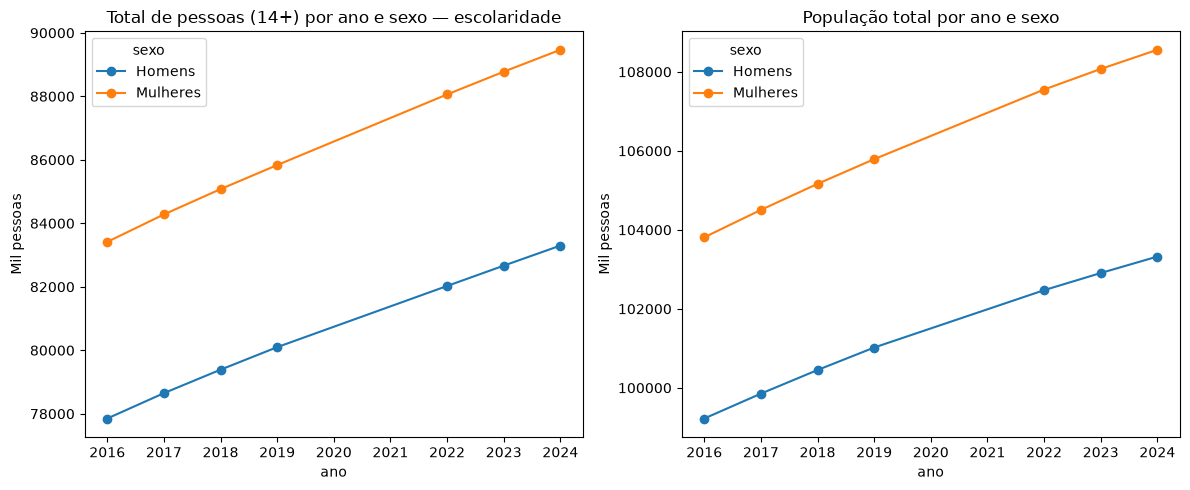

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
esc.groupby(['ano', 'sexo'])['valor'].sum().unstack().plot(ax=axes[0], marker='o')
axes[0].set_title('Total de pessoas (14+) por ano e sexo — escolaridade')
axes[0].set_ylabel('Mil pessoas')

pop.groupby(['ano', 'sexo'])['valor'].sum().unstack().plot(ax=axes[1], marker='o')
axes[1].set_title('População total por ano e sexo')
axes[1].set_ylabel('Mil pessoas')
plt.tight_layout()
plt.show()

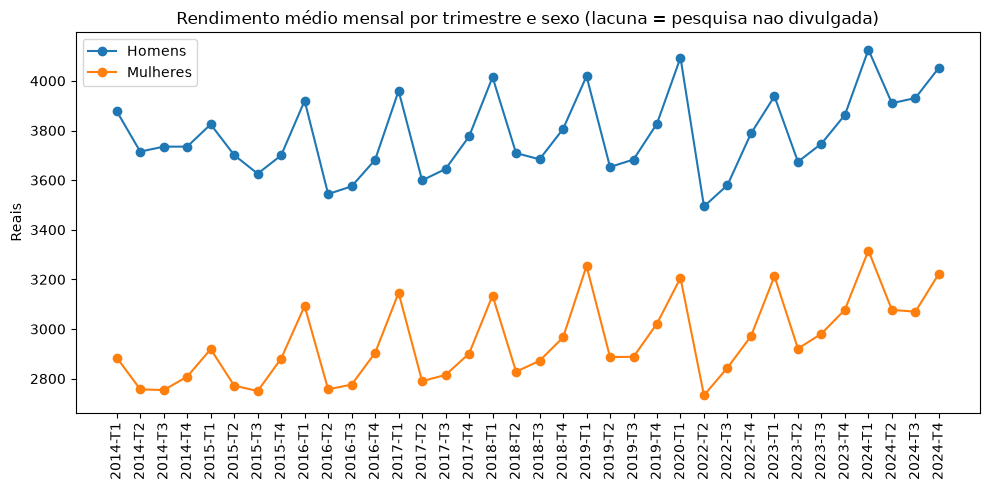

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ren_plot = ren.copy()
ren_plot['periodo'] = ren_plot['ano'].astype(str) + '-T' + ren_plot['trimestre'].astype(str)
ren_plot = ren_plot.sort_values(['ano', 'trimestre'])
for sexo, grupo in ren_plot.groupby('sexo'):
    ax.plot(grupo['periodo'], grupo['valor'], marker='o', label=sexo)
ax.set_title('Rendimento médio mensal por trimestre e sexo (lacuna = pesquisa nao divulgada)')
ax.set_ylabel('Reais')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

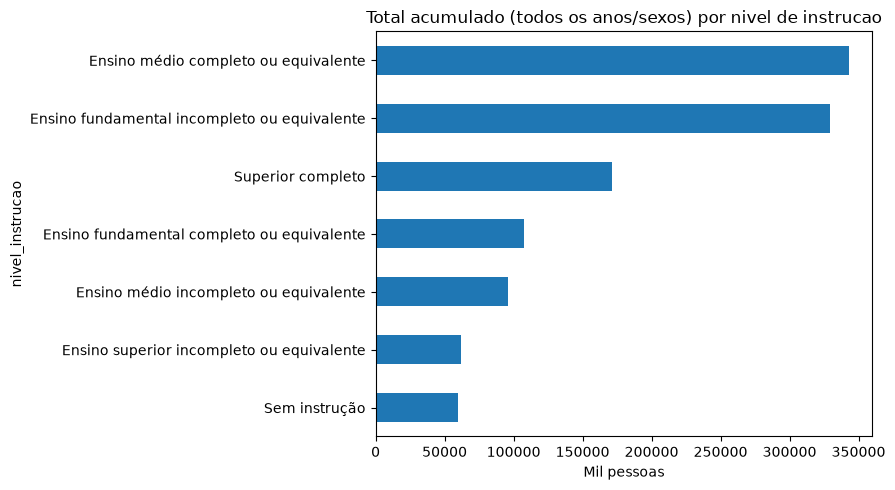

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
esc.groupby('nivel_instrucao')['valor'].sum().sort_values().plot(kind='barh', ax=ax)
ax.set_title('Total acumulado (todos os anos/sexos) por nivel de instrucao')
ax.set_xlabel('Mil pessoas')
plt.tight_layout()
plt.show()

## 12. Conclusões — transformações necessárias para a Silver

- **Nulos em `trimestre`:** manter como estão — são nulos estruturalmente esperados (tabela anual), não dado ausente. Nenhuma remoção de linha se justifica por causa deles.
- **Deduplicação:** nenhuma duplicata encontrada, mas a mesma proteção estrutural aplicada na Silver do ISAPS (ver [tratamento_silver_isaps.ipynb](tratamento_silver_isaps.ipynb)) se justifica aqui pelo mesmo motivo — custo zero, proteção contra reprocessamento futuro.
- **Tradução PT-BR:** **não se aplica** — diferente do ISAPS, os dados do IBGE já nascem em português. Esse é um contraste importante com a Silver do ISAPS: nem toda camada Silver precisa da mesma transformação.
- **Tipo de `trimestre`:** hoje é `object` (mistura de `None` e inteiro); a Silver deve convertê-lo para um inteiro anulável (`pandas.Int64`/`Int64Dtype`), evitando o tipo genérico `object`.
- **Unidade explícita:** extrair `Mil pessoas`/`Reais` de `variavel` para uma coluna `unidade`, e documentar explicitamente (no schema `pandera` ou em texto) que `valor` em `renda` é uma média, não uma contagem — para não ser somada por engano.
- **Lacunas temporais:** preservar como ausência de linha, não preencher com zero/interpolação.
- **Tabelas continuam separadas:** `escolaridade`, `populacao` e `renda` seguem como três tabelas Silver distintas (schemas diferentes, unidades diferentes) — a verificação cruzada da seção 8 é um bom candidato a virar uma tabela derivada na Gold, não uma fusão das tabelas na Silver.
- **Validação de schema (`pandera`):** um schema por tabela, com `trimestre` nullable e `valor >= 0` — mesmo padrão da Silver do ISAPS.